# Chapter 129 — Distance in Vector Space

> **Prerequisites:** Vector Length / Norm (ch128), Geometric Interpretation (ch122)
> **You will learn:**
> - How distance between two vectors is computed from their difference
> - The connection between norm and metric
> - Applications: nearest neighbor search, clustering, similarity

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The **distance** between two vectors **u** and **v** is the norm of their difference:

$$d(\mathbf{u}, \mathbf{v}) = \|\mathbf{u} - \mathbf{v}\|$$

This generalizes the familiar 2D distance formula to any number of dimensions, and to any choice of norm. The Euclidean distance (L2) is the most common, but L1 and L∞ distances each have natural applications.

**Common misconception:** The distance between two vectors is not `np.dot(u - v, u - v)` — that is the squared distance. Always take the square root for the actual distance.

---

## 2. Intuition & Mental Models

**Geometric model:** The distance from **u** to **v** is the length of the arrow from **v** to **u** (the vector **u** − **v**). This arrow is the displacement vector discussed in ch122.

**Metric model:** A distance function is a **metric** if it satisfies: non-negativity, symmetry ($d(u,v) = d(v,u)$), identity ($d(u,u) = 0$), and triangle inequality ($d(u,w) \leq d(u,v) + d(v,w)$). Every norm induces a valid metric by $d(u,v) = \|u-v\|$.

Recall from ch128 (Vector Length): $\|\mathbf{v}\|$ is the norm. Distance is $\|\mathbf{u} - \mathbf{v}\|$ — the norm of the displacement.

---

## 3. Visualization & Implementation

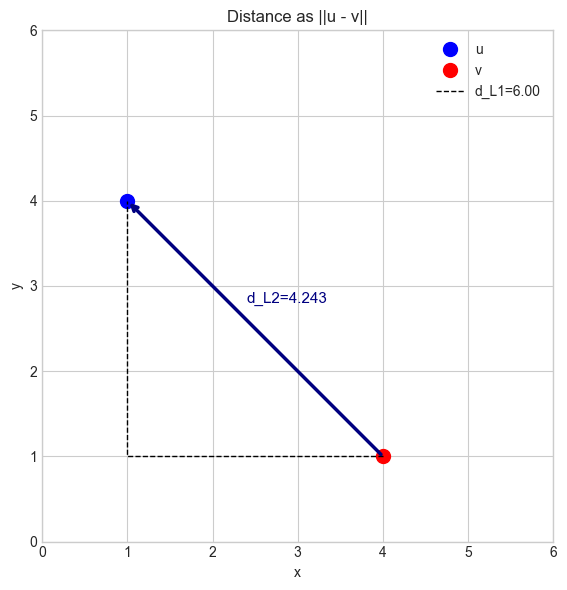

In [1]:
# --- Visualization: Distance as the norm of the difference ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

u = np.array([1.0, 4.0])
v = np.array([4.0, 1.0])
diff = u - v

d_l2 = np.linalg.norm(diff, 2)
d_l1 = np.linalg.norm(diff, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(*u, 'bo', markersize=10, label='u')
ax.plot(*v, 'ro', markersize=10, label='v')
ax.annotate('', xy=u, xytext=v,
            arrowprops=dict(arrowstyle='->', color='navy', lw=2.5))
ax.text(2.4, 2.8, f'd_L2={d_l2:.3f}', fontsize=11, color='navy')
ax.plot([v[0], u[0], u[0]], [v[1], v[1], u[1]], 'k--', lw=1, label=f'd_L1={d_l1:.2f}')
ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.set_title('Distance as ||u - v||')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout(); plt.show()

In [2]:
# --- Implementation: distance functions ---
import numpy as np

def euclidean_distance(u, v):
    """L2 distance between u and v."""
    return np.linalg.norm(np.asarray(u, float) - np.asarray(v, float))

def manhattan_distance(u, v):
    """L1 distance between u and v."""
    return np.linalg.norm(np.asarray(u, float) - np.asarray(v, float), 1)

def pairwise_distances(X, p=2):
    """
    Compute all pairwise Lp distances between rows of X.

    Args:
        X: ndarray shape (n, d)
        p: norm order

    Returns:
        D: ndarray shape (n, n) — D[i,j] = dist(X[i], X[j])
    """
    n = X.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = np.linalg.norm(X[i] - X[j], p)
            D[i, j] = D[j, i] = d
    return D


# Test
u = np.array([1.0, 4.0])
v = np.array([4.0, 1.0])
print("Euclidean:", euclidean_distance(u, v))
print("Manhattan:", manhattan_distance(u, v))

X = np.array([[0,0],[3,4],[1,1]], dtype=float)
D = pairwise_distances(X)
print("\nPairwise L2 distances:\n", D)

Euclidean: 4.242640687119285
Manhattan: 6.0

Pairwise L2 distances:
 [[0.         5.         1.41421356]
 [5.         0.         3.60555128]
 [1.41421356 3.60555128 0.        ]]


## 4. Experiments

In [3]:
# --- Experiment: Curse of dimensionality — distances concentrate ---
# Hypothesis: in high dimensions, all pairwise distances converge to the same value.
# Try changing: DIM
import numpy as np

N = 500  # number of points
np.random.seed(0)

for DIM in [2, 10, 50, 200, 1000]:
    X = np.random.randn(N, DIM)
    # compute a sample of pairwise distances
    idx1 = np.random.randint(0, N, 1000)
    idx2 = np.random.randint(0, N, 1000)
    dists = np.linalg.norm(X[idx1] - X[idx2], axis=1)
    print(f"dim={DIM:5d}  mean={dists.mean():.3f}  std={dists.std():.3f}  cv={dists.std()/dists.mean():.4f}")

dim=    2  mean=1.714  std=0.918  cv=0.5357
dim=   10  mean=4.434  std=1.018  cv=0.2295
dim=   50  mean=9.923  std=1.055  cv=0.1063
dim=  200  mean=19.797  std=1.581  cv=0.0798
dim= 1000  mean=44.690  std=0.976  cv=0.0218


## 5. Exercises

**Easy 1.** Compute L2 distance between (1,2,3) and (4,6,3). *(Expected: 5)*

**Medium 1.** Given 5 points in 3D, find the pair with minimum L2 distance. Do the same with L1 distance. Are the closest pairs the same?

**Hard.** Implement an O(n²) brute-force all-pairs distance matrix for n=500 points in 10D. Time it. Then implement the same using NumPy broadcasting without explicit loops. Report the speedup.

---

## 6. Summary & Connections

- Distance between vectors: $d(\mathbf{u}, \mathbf{v}) = \|\mathbf{u} - \mathbf{v}\|$.
- Every norm defines a valid metric (distance function).
- In high dimensions, L2 distances concentrate — motivation for cosine similarity *(ch132)*.

**Backward connection:** Generalizes the 2D distance formula from ch094 to arbitrary dimension and norm choice.

**Forward connections:**
- This will reappear in ch135 — Orthogonality, where two vectors at 90° have a specific distance relationship.
- This will reappear in ch175 — Linear Regression, where residuals are distances in the output space.